# Outliers, Leverage, and InfluenceAuthor: Brad Sheese---NOTE: If you want to save your work select the following from the menu above:**File  --> Save a copy in Drive**If you work on the copy you made all changes will be saved to Google Drive. If you do not save your own copy, you can work in 'playground mode' instead, and any changes you make will be lost after you're done.

In [1]:
#@title Getting started? Execute this cell first.
#@markdown Click on the arrow to the left to execute this cell.

exercise_name = '17.1.6 Outliers, Leverage, and Influence'

import os
import sys
import math

class MockExerciseReport:
    @staticmethod
    def exercise_time_difficulty_report(name):
        pass
    @staticmethod
    def display_form(q):
        print("Exercise response form for: {}".format(q))
    @staticmethod
    def submit_exercise_response(name, q):
        print("Exercise {} submitted!".format(name))
    er_question_list = []

exercise_report_response = MockExerciseReport()
exercise_report_response.exercise_time_difficulty_report(exercise_name)


In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


## IntroductionIn previous notebooks we've fit regression models and assessed them with residual plots. But what happens when individual data points don't follow the pattern? Not all unusual points are created equal.This notebook covers three types of unusual points in regression:- **Outliers**: points with unusually large residuals- **Leverage points**: points with extreme predictor values- **Influential points**: points that actually change the regression lineUnderstanding these distinctions is essential for responsible model building.

## Three Types of Unusual Points**Outlier**: a point that stands out from the rest of the data. It has a large residual -- the vertical distance from the point to the regression line is much larger than for other points.**Leverage point**: an outlier with an extreme $x$ value. It sits horizontally far from the center of the data cloud. These points "pull harder" on the regression line because they have more leverage.**Influential point**: a leverage point that actually *changes the slope* of the least squares line. If you removed it and re-fit the model, the line would move noticeably.**Key insight**: being outlying in $x$ or $y$ alone does NOT make a point influential. What matters is whether the point is outlying relative to the *bivariate* model -- that is, whether it falls off the trend that the rest of the data follows.

## Why This MattersA single influential point can dramatically change your model's conclusions. Consider:- In **finance**, ignoring market crashes (the "outliers") leads to risk models that catastrophically underestimate losses- In **medicine**, excluding rare but real patient cases leads to biased treatment recommendations- In **science**, removing anomalous observations can hide new phenomena waiting to be discoveredThe goal is **not** to automatically remove outliers. The goal is to understand their impact on your model and make informed decisions.

## The Diagnostic ApproachWhen you identify an unusual point:1. **Identify** it using residual plots and scatterplots2. **Investigate** the cause: data entry error? Special case? New phenomenon?3. **Compare** the model with and without the point4. **Report** both results and discuss the differenceIf the slopes, intercepts, or R-squared (coefficient of determination) values differ substantially, the point is influential and deserves careful attention.

## Six Illustrative ScenariosWe'll examine six fabricated datasets, each demonstrating a different type of unusual point. For each scenario you'll create the plots, fit the models, and compare results.

### Scenario 1: Outlier in $y$ OnlyA point with an extreme $y$ value but a typical $x$ value. This point has a large residual but sits in the middle of the $x$ range.**Task:** Create the dataset, fit the model, and create both a scatterplot and residual plot.

In [3]:
# Scenario 1: Outlier in y only
np.random.seed(1)
n = 40
x1 = np.linspace(0, 10, n)
y1 = 2 + 1.5 * x1 + np.random.normal(0, 1, n)
# Add y-only outlier
x1 = np.append(x1, 5.0)
y1 = np.append(y1, 25.0)

# Fit model with outlier
# Create scatterplot with regression line
# Create residual plot
# Compare model with and without the outlier
# enter your code here



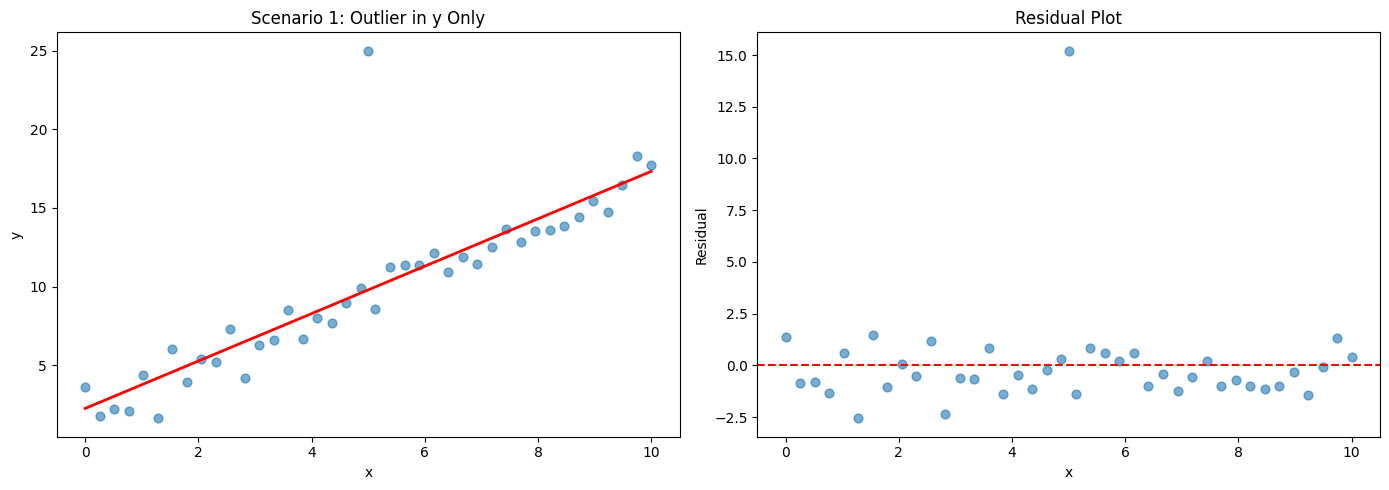

With outlier:    slope = 1.508, intercept = 2.25, R2 = 0.744
Without outlier: slope = 1.508, intercept = 1.87, R2 = 0.955


In [4]:
# Solution: Check your work
X1 = x1.reshape(-1, 1)
model1 = LinearRegression().fit(X1, y1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatterplot
axes[0].scatter(x1, y1, alpha=0.6, s=40)
axes[0].plot(np.sort(x1), model1.predict(X1[np.argsort(x1)]), color='red', linewidth=2)
axes[0].set_title('Scenario 1: Outlier in y Only')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Residual plot
resid1 = y1 - model1.predict(X1).flatten()
axes[1].scatter(x1, resid1, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

# Compare with and without outlier
X1_no = x1[:-1].reshape(-1, 1)
y1_no = y1[:-1]
model1_no = LinearRegression().fit(X1_no, y1_no)

print("With outlier:    slope = {:.3f}, intercept = {:.2f}, R2 = {:.3f}".format(
    model1.coef_.item(), model1.intercept_.item(), model1.score(X1, y1)))
print("Without outlier: slope = {:.3f}, intercept = {:.2f}, R2 = {:.3f}".format(
    model1_no.coef_.item(), model1_no.intercept_.item(), model1_no.score(X1_no, y1_no)))


### Interpretation: Scenario 1The outlier has a very large residual (visible as the top point in the residual plot) but the slope barely changes when it's removed. This point is an **outlier** but **not influential**. Because it sits in the middle of the $x$ range, it doesn't have much leverage to pull the line.

### Scenario 2: Outlier in $x$ and $y$ but *On* the TrendA point far from the main cloud in both directions, but it follows the overall linear trend.**Task:** Create the dataset and compare models with and without the far point.

In [5]:
# Scenario 2: Far point on the trend
np.random.seed(2)
n = 40
x2 = np.linspace(0, 10, n)
y2 = 2 + 1.5 * x2 + np.random.normal(0, 1, n)
# Add point on the trend but far away
x2 = np.append(x2, 18.0)
y2 = np.append(y2, 2 + 1.5 * 18.0 + np.random.normal(0, 1))

# Fit model, create plots, compare with/without
# enter your code here



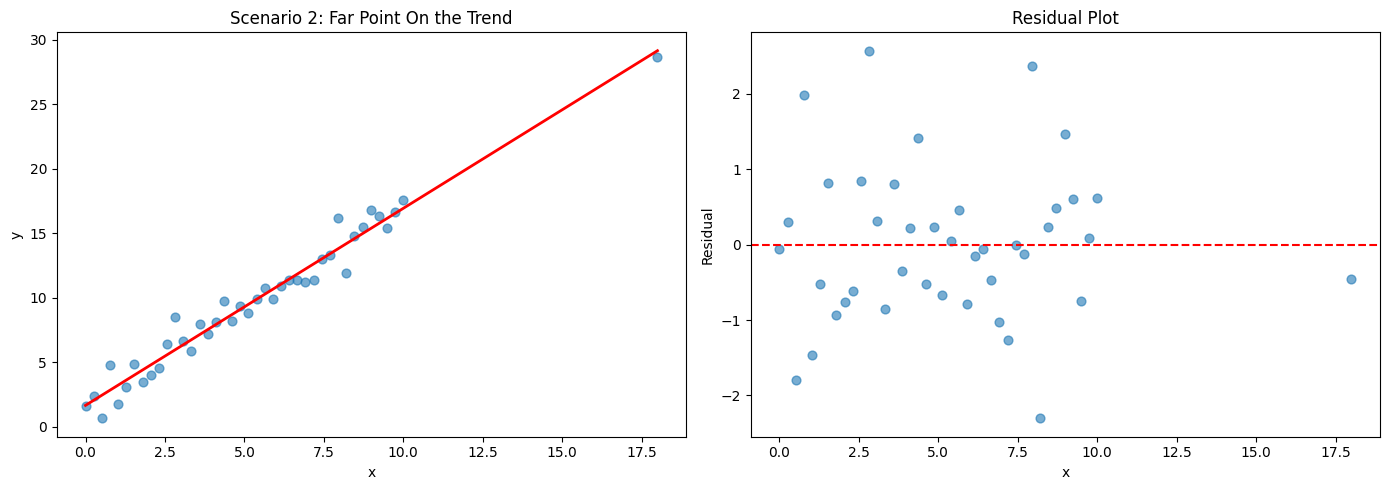

With far point:   slope = 1.528, intercept = 1.64, R2 = 0.966
Without far point: slope = 1.545, intercept = 1.57, R2 = 0.952


In [6]:
# Solution: Check your work
X2 = x2.reshape(-1, 1)
model2 = LinearRegression().fit(X2, y2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x2, y2, alpha=0.6, s=40)
axes[0].plot(np.sort(x2), model2.predict(X2[np.argsort(x2)]), color='red', linewidth=2)
axes[0].set_title('Scenario 2: Far Point On the Trend')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

resid2 = y2 - model2.predict(X2).flatten()
axes[1].scatter(x2, resid2, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

X2_no = x2[:-1].reshape(-1, 1)
y2_no = y2[:-1]
model2_no = LinearRegression().fit(X2_no, y2_no)

print("With far point:   slope = {:.3f}, intercept = {:.2f}, R2 = {:.3f}".format(
    model2.coef_.item(), model2.intercept_.item(), model2.score(X2, y2)))
print("Without far point: slope = {:.3f}, intercept = {:.2f}, R2 = {:.3f}".format(
    model2_no.coef_.item(), model2_no.intercept_.item(), model2_no.score(X2_no, y2_no)))


### Interpretation: Scenario 2This point has **high leverage** (extreme $x$ value) but is **not influential** because it falls right on the trend line. In fact, it *strengthens* the model by confirming the pattern at extreme values. Notice that R-squared (coefficient of determination) actually increases when this point is included -- it makes the linear relationship clearer.**Takeaway**: not all extreme points are bad. A high-leverage point that confirms the trend is valuable.

### Scenario 3: The Influential PointA point that is extreme in both $x$ and $y$ AND falls *off* the trend. This is the classic influential point.**Task:** Create the dataset and observe how the outlier dramatically changes the slope.

In [7]:
# Scenario 3: The influential point
np.random.seed(3)
n = 40
x3 = np.linspace(0, 10, n)
y3 = 2 + 1.5 * x3 + np.random.normal(0, 1, n)
# Add influential outlier
x3 = np.append(x3, 18.0)
y3 = np.append(y3, 5.0)

# Fit model, create plots, compare with/without
# enter your code here



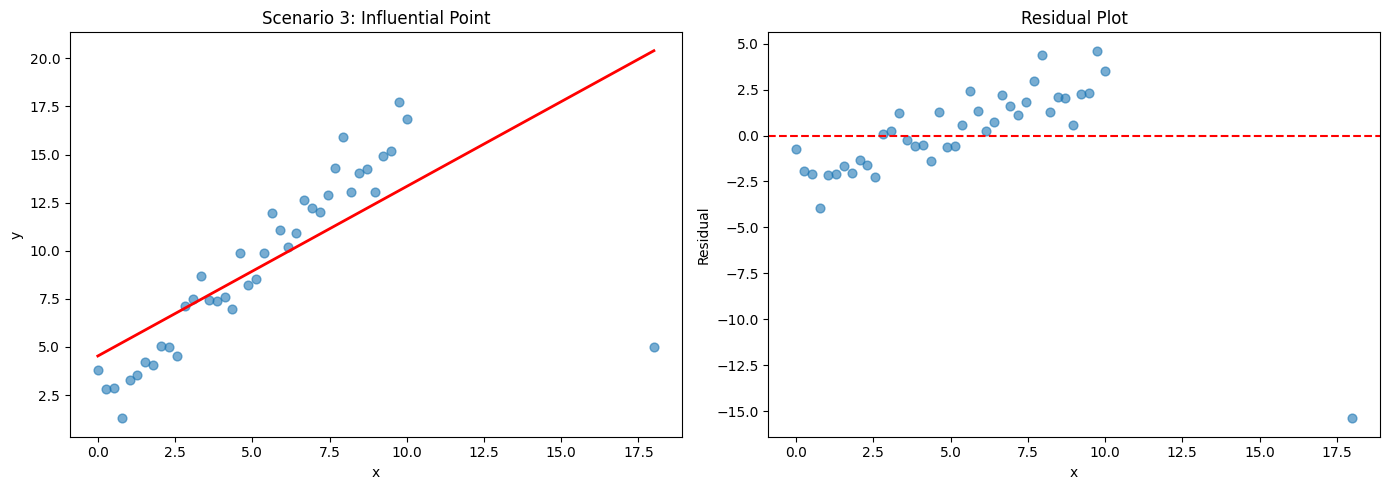

With outlier:    slope = 0.881, intercept = 4.53, R2 = 0.502
Without outlier: slope = 1.453, intercept = 2.06, R2 = 0.950


In [8]:
# Solution: Check your work
X3 = x3.reshape(-1, 1)
model3 = LinearRegression().fit(X3, y3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x3, y3, alpha=0.6, s=40)
axes[0].plot(np.sort(x3), model3.predict(X3[np.argsort(x3)]), color='red', linewidth=2)
axes[0].set_title('Scenario 3: Influential Point')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

resid3 = y3 - model3.predict(X3).flatten()
axes[1].scatter(x3, resid3, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

X3_no = x3[:-1].reshape(-1, 1)
y3_no = y3[:-1]
model3_no = LinearRegression().fit(X3_no, y3_no)

print("With outlier:    slope = {:.3f}, intercept = {:.2f}, R2 = {:.3f}".format(
    model3.coef_.item(), model3.intercept_.item(), model3.score(X3, y3)))
print("Without outlier: slope = {:.3f}, intercept = {:.2f}, R2 = {:.3f}".format(
    model3_no.coef_.item(), model3_no.intercept_.item(), model3_no.score(X3_no, y3_no)))


### Interpretation: Scenario 3The influential point dramatically pulls the regression line downward. The slope changes substantially when it's removed, and R-squared (coefficient of determination) drops significantly. This point is both a **leverage point** (extreme $x$) and **influential** (changes the slope).**What to do**: investigate this point. Is it a data entry error? A special case with an interesting explanation? Report the model both with and without this point.

### Scenario 4: Secondary Cloud of OutliersNot just one outlier but a small cluster of points forming a secondary pattern.**Task:** Create the dataset with a secondary cloud and compare models.

In [9]:
# Scenario 4: Secondary cloud of outliers
np.random.seed(4)
n = 40
x4 = np.linspace(0, 10, n)
y4 = 2 + 1.5 * x4 + np.random.normal(0, 0.8, n)
# Add secondary cloud
x4_sec = np.array([8, 9, 10, 8.5, 9.5, 10.5])
y4_sec = np.array([20, 22, 19, 21, 20.5, 21.5])
x4 = np.append(x4, x4_sec)
y4 = np.append(y4, y4_sec)

# Fit model, create plots, compare with main cloud only
# enter your code here



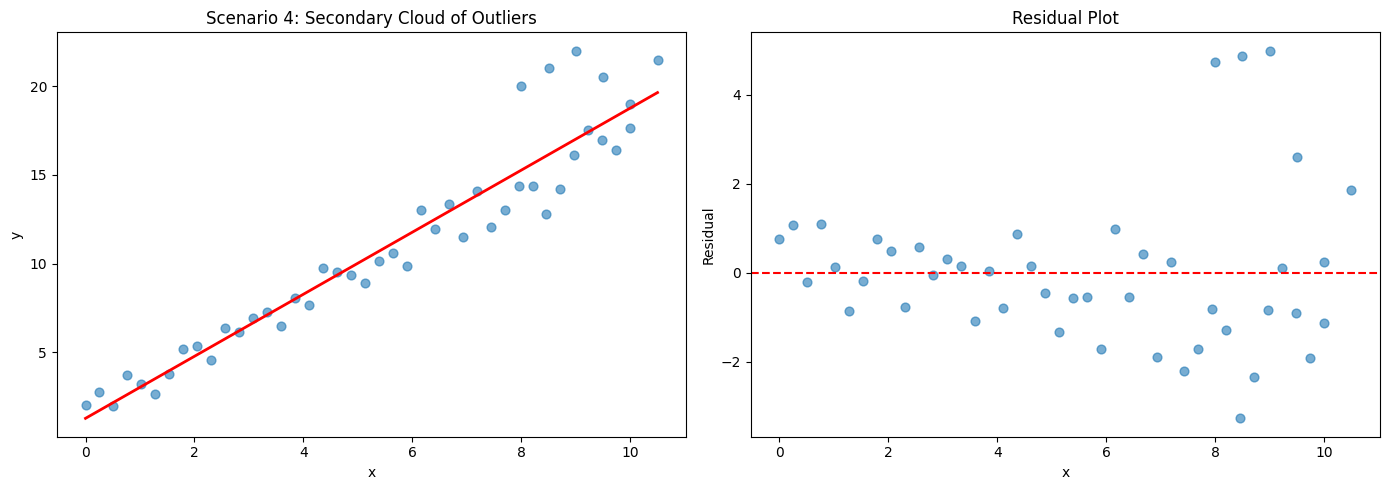

With secondary cloud: slope = 1.749, R2 = 0.912
Main cloud only:      slope = 1.537, R2 = 0.969


In [10]:
# Solution: Check your work
X4 = x4.reshape(-1, 1)
model4 = LinearRegression().fit(X4, y4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x4, y4, alpha=0.6, s=40)
axes[0].plot(np.sort(x4), model4.predict(X4[np.argsort(x4)]), color='red', linewidth=2)
axes[0].set_title('Scenario 4: Secondary Cloud of Outliers')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

resid4 = y4 - model4.predict(X4).flatten()
axes[1].scatter(x4, resid4, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

# Model on main cloud only
X4_main = x4[:n].reshape(-1, 1)
y4_main = y4[:n]
model4_main = LinearRegression().fit(X4_main, y4_main)

print("With secondary cloud: slope = {:.3f}, R2 = {:.3f}".format(
    model4.coef_.item(), model4.score(X4, y4)))
print("Main cloud only:      slope = {:.3f}, R2 = {:.3f}".format(
    model4_main.coef_.item(), model4_main.score(X4_main, y4_main)))


### Interpretation: Scenario 4The secondary cloud pulls the regression line upward at the right end, distorting the fit across the entire range. The residual plot clearly shows two groups: the main cloud (residuals near 0) and the secondary cloud (all positive residuals).**What to investigate**: Is there a reason for the dual clouds? Perhaps there are two subpopulations that should be modeled separately. This is a case where including a categorical predictor (which group?) would dramatically improve the model.

### Scenario 5: Creating a Spurious TrendThe most dangerous case: no real trend in the main cloud, but one outlier creates the illusion of a relationship.**Task:** Create the dataset and observe how one outlier creates a false trend.
Note: This is also an example of **extrapolation** risk -- the outlier creates a trend that doesn't exist in the observed data range, and any predictions based on this false trend would be unreliable.


In [11]:
# Scenario 5: Creating a spurious trend
np.random.seed(5)
n = 40
x5 = np.linspace(0, 10, n)
y5 = 10 + np.random.normal(0, 2, n)
# Add one outlier that creates a spurious trend
x5 = np.append(x5, 18.0)
y5 = np.append(y5, 30.0)

# Fit model, create plots, compare with/without
# enter your code here



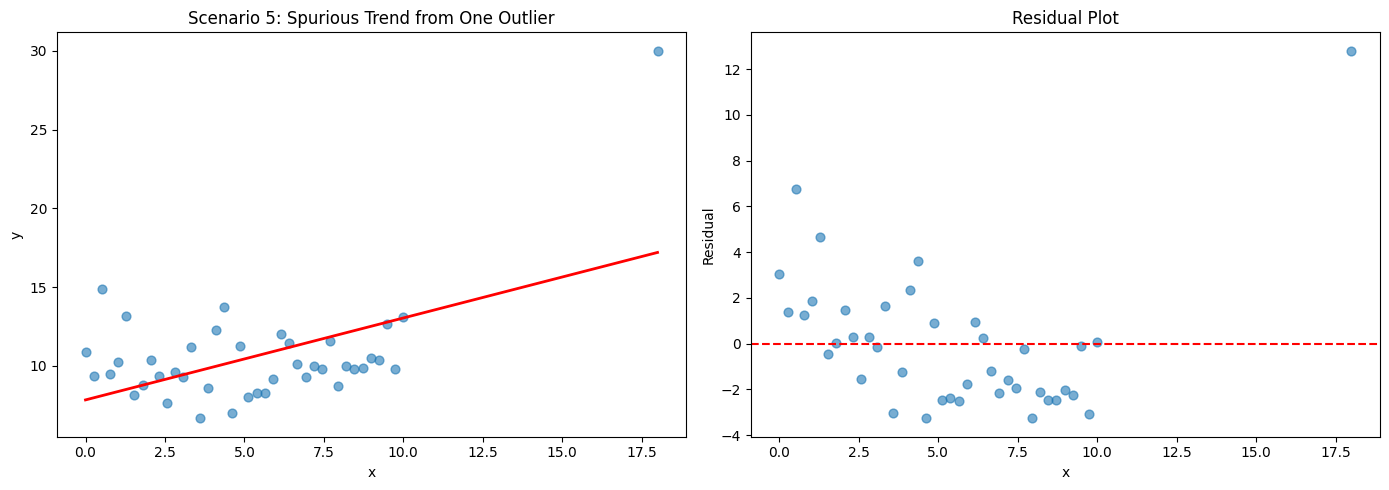

With outlier:    slope = 0.520, R2 = 0.271
Without outlier: slope = 0.045, R2 = 0.005


In [12]:
# Solution: Check your work
X5 = x5.reshape(-1, 1)
model5 = LinearRegression().fit(X5, y5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x5, y5, alpha=0.6, s=40)
axes[0].plot(np.sort(x5), model5.predict(X5[np.argsort(x5)]), color='red', linewidth=2)
axes[0].set_title('Scenario 5: Spurious Trend from One Outlier')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

resid5 = y5 - model5.predict(X5).flatten()
axes[1].scatter(x5, resid5, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

X5_no = x5[:-1].reshape(-1, 1)
y5_no = y5[:-1]
model5_no = LinearRegression().fit(X5_no, y5_no)

print("With outlier:    slope = {:.3f}, R2 = {:.3f}".format(
    model5.coef_.item(), model5.score(X5, y5)))
print("Without outlier: slope = {:.3f}, R2 = {:.3f}".format(
    model5_no.coef_.item(), model5_no.score(X5_no, y5_no)))


### Interpretation: Scenario 5This is the **most dangerous** type of influence. The main cloud shows no trend at all (slope near 0), but the single outlier creates the illusion of a strong positive relationship. With the outlier, R-squared (coefficient of determination) suggests a meaningful relationship. Without it, R-squared (coefficient of determination) is essentially zero.**Lesson**: always visualize your data. A single influential point can create a statistically significant but entirely false conclusion.

### Scenario 6: High Leverage, Not InfluentialA point far in $x$ but right on the trend line -- the valuable kind of extreme point.**Task:** Create the dataset and verify that the high-leverage point does not change the slope.

In [13]:
# Scenario 6: High leverage, on the line
np.random.seed(6)
n = 40
x6 = np.linspace(0, 10, n)
y6 = 2 + 1.5 * x6 + np.random.normal(0, 1, n)
# Add high-leverage point on the line
x6 = np.append(x6, 20.0)
y6 = np.append(y6, 2 + 1.5 * 20.0)

# Fit model, create plots, compare with/without
# enter your code here



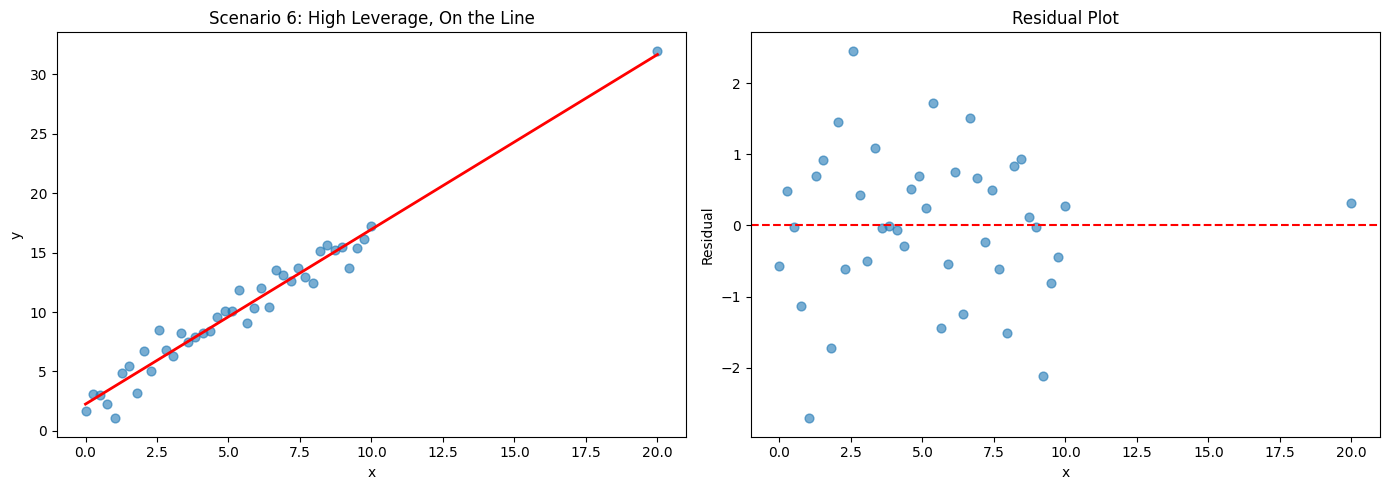

With high-leverage point: slope = 1.471, R2 = 0.965
Without it:               slope = 1.458, R2 = 0.944


In [14]:
# Solution: Check your work
X6 = x6.reshape(-1, 1)
model6 = LinearRegression().fit(X6, y6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x6, y6, alpha=0.6, s=40)
axes[0].plot(np.sort(x6), model6.predict(X6[np.argsort(x6)]), color='red', linewidth=2)
axes[0].set_title('Scenario 6: High Leverage, On the Line')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

resid6 = y6 - model6.predict(X6).flatten()
axes[1].scatter(x6, resid6, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

X6_no = x6[:-1].reshape(-1, 1)
y6_no = y6[:-1]
model6_no = LinearRegression().fit(X6_no, y6_no)

print("With high-leverage point: slope = {:.3f}, R2 = {:.3f}".format(
    model6.coef_.item(), model6.score(X6, y6)))
print("Without it:               slope = {:.3f}, R2 = {:.3f}".format(
    model6_no.coef_.item(), model6_no.score(X6_no, y6_no)))


### Interpretation: Scenario 6This point has **high leverage** (extreme $x$) but is **not influential** because it confirms the existing trend. The slope barely changes when it's removed. In fact, R-squared (coefficient of determination) *increases* because this point extends the range of $x$, making the linear relationship clearer.**Takeaway**: high-leverage points that fall on the trend are valuable data points. They strengthen the model by confirming the pattern at extreme values.

## Summary: Six Types of Unusual Points| Scenario | Outlying in $x$? | Outlying in $y$? | On the trend? | Influential? ||---|---|---|---|---|| 1: $y$-only outlier | No | Yes | N/A | No (slight effect) || 2: Far point on trend | Yes | Yes | Yes | No || 3: Off-trend far point | Yes | Yes | No | **Yes** || 4: Secondary cloud | Partial | Partial | No | **Yes** || 5: Spurious trend | Yes | Yes | No | **Yes** (dangerous) || 6: High leverage, on line | Yes | No | Yes | No |**Key pattern**: Points are influential when they are extreme in $x$ (high leverage) AND fall off the trend that the rest of the data follows.

## Decision Framework for Unusual PointsWhen you identify an unusual point, follow these steps:1. **Identify**: Use residual plots (large residuals) and scatterplots (extreme $x$ values)2. **Investigate**: Is it a data entry error? A special case? A new phenomenon?3. **Compare**: Fit the model with and without the point. Do the slopes differ substantially?4. **Decide**:   - If it's a data error: correct or remove it   - If it's a valid but unusual observation: keep it, but report both analyses   - If it reveals a subpopulation: consider adding a categorical predictor5. **Report**: Always present both analyses (with and without) and discuss the difference

## Best Practices**Don't remove outliers without a very good reason.** Models that ignore exceptional cases often perform poorly.From the OpenIntro text:> *If a financial firm ignored the largest market swings -- the "outliers" -- they would soon go bankrupt by making poorly thought-out investments.*Exceptional cases are often the most interesting and informative. The goal is not to produce a clean-looking model but to produce an *honest* one.**Always**:- Visualize your data before and after fitting- Check residual plots for unusual points- Compare models with and without influential points- Report both results when they differ

## Connection to Residual PlotsResidual plots are excellent at identifying **outliers** -- points with large residuals stand out clearly. But residual plots alone cannot tell you about **leverage** or **influence**:- A point can have a small residual but high leverage (Scenario 6)- A point can have a large residual but no influence if it's in the middle of the $x$ range (Scenario 1)- Only by comparing models with and without the point can you assess influenceYou need both the scatterplot (for leverage) and the model comparison (for influence).

## Practice Exercises

### Exercise 1: Identify the TypeLook at the scatterplot below. Without running any code, answer:1. Is the highlighted point an outlier, a leverage point, an influential point, or some combination?2. If you removed this point, would the slope increase, decrease, or stay about the same?

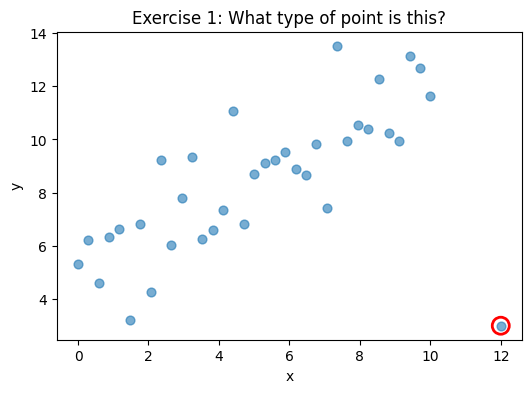

In [15]:
np.random.seed(77)
n_ex1 = 35
x_ex1 = np.linspace(0, 10, n_ex1)
y_ex1 = 5 + 0.8 * x_ex1 + np.random.normal(0, 1.5, n_ex1)
x_ex1 = np.append(x_ex1, 12.0)
y_ex1 = np.append(y_ex1, 3.0)

plt.figure(figsize=(6, 4))
plt.scatter(x_ex1, y_ex1, alpha=0.6, s=40)
plt.scatter([12], [3], s=150, facecolors='none', edgecolors='red', linewidth=2, zorder=5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Exercise 1: What type of point is this?')
plt.show()

# Now fit and compare
# enter your code here



In [16]:
# Solution: Check your work
X_ex1 = x_ex1.reshape(-1, 1)
model_ex1 = LinearRegression().fit(X_ex1, y_ex1)
X_ex1_no = x_ex1[:-1].reshape(-1, 1)
y_ex1_no = y_ex1[:-1]
model_ex1_no = LinearRegression().fit(X_ex1_no, y_ex1_no)

print("With point:    slope = {:.3f}".format(model_ex1.coef_.item()))
print("Without point: slope = {:.3f}".format(model_ex1_no.coef_.item()))
print()
print("This point is a leverage point (extreme x) AND influential")
print("(it pulls the slope downward). Removing it increases the slope.")


With point:    slope = 0.504
Without point: slope = 0.704

This point is a leverage point (extreme x) AND influential
(it pulls the slope downward). Removing it increases the slope.


### Exercise 2: Quantify InfluenceFor the dataset below, fit the model with and without the suspicious point. Compare slopes, intercepts, and R-squared (coefficient of determination). Is the point influential?

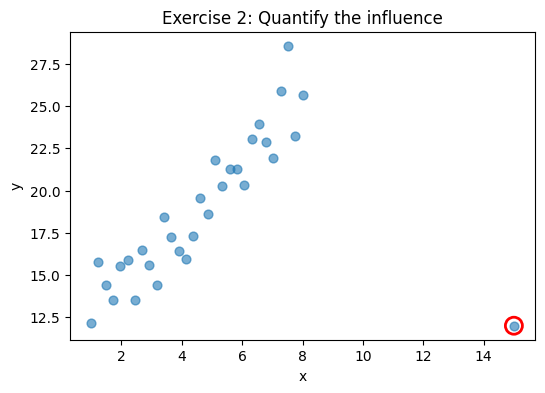

In [17]:
np.random.seed(88)
n_ex2 = 30
x_ex2 = np.linspace(1, 8, n_ex2)
y_ex2 = 10 + 2 * x_ex2 + np.random.normal(0, 1.5, n_ex2)
x_ex2 = np.append(x_ex2, 15.0)
y_ex2 = np.append(y_ex2, 12.0)

plt.figure(figsize=(6, 4))
plt.scatter(x_ex2, y_ex2, alpha=0.6, s=40)
plt.scatter([15], [12], s=150, facecolors='none', edgecolors='red', linewidth=2, zorder=5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Exercise 2: Quantify the influence')
plt.show()

# Fit with and without the point and compare
# enter your code here



In [18]:
# Solution: Check your work
X_ex2 = x_ex2.reshape(-1, 1)
model_ex2 = LinearRegression().fit(X_ex2, y_ex2)
X_ex2_no = x_ex2[:-1].reshape(-1, 1)
y_ex2_no = y_ex2[:-1]
model_ex2_no = LinearRegression().fit(X_ex2_no, y_ex2_no)

print("With point:    slope = {:.3f}, intercept = {:.2f}, R2 = {:.3f}".format(
    model_ex2.coef_.item(), model_ex2.intercept_.item(), model_ex2.score(X_ex2, y_ex2)))
print("Without point: slope = {:.3f}, intercept = {:.2f}, R2 = {:.3f}".format(
    model_ex2_no.coef_.item(), model_ex2_no.intercept_.item(), model_ex2_no.score(X_ex2_no, y_ex2_no)))


With point:    slope = 0.712, intercept = 15.36, R2 = 0.217
Without point: slope = 1.838, intercept = 10.76, R2 = 0.870


### Exercise 3: Real Data DiagnosisUse the **MPG** dataset from Seaborn. Fit a model predicting `mpg` from `weight`. Identify the observation with the largest absolute residual. Check if it has high leverage and whether it is influential by comparing the model with and without that observation.

In [19]:
# Load the MPG dataset
# Fit model: weight -> mpg
# Find observation with largest residual
# Check if it has high leverage
# Compare model with and without the point
# enter your code here



In [20]:
# Solution: Check your work
mpg = sns.load_dataset('mpg').dropna()

X_mpg = mpg['weight'].values.reshape(-1, 1)
y_mpg = mpg['mpg'].values.reshape(-1, 1)
model_mpg = LinearRegression().fit(X_mpg, y_mpg)

preds = model_mpg.predict(X_mpg).flatten()
resids = y_mpg.flatten() - preds
max_resid_idx = np.argmax(np.abs(resids))

print("Observation with largest residual:")
print("  Car: {}".format(mpg.iloc[max_resid_idx]['name']))
print("  Weight: {:.0f} lbs".format(mpg.iloc[max_resid_idx]['weight']))
print("  Actual MPG: {:.1f}".format(mpg.iloc[max_resid_idx]['mpg']))
print("  Predicted MPG: {:.1f}".format(preds[max_resid_idx]))
print("  Residual: {:.1f}".format(resids[max_resid_idx]))
print()

print("Weight range: {:.0f} to {:.0f} lbs".format(
    mpg['weight'].min(), mpg['weight'].max()))
print("Mean weight: {:.0f} lbs".format(mpg['weight'].mean()))
print()

mask = np.ones(len(mpg), dtype=bool)
mask[max_resid_idx] = False
X_no = mpg.loc[mask, 'weight'].values.reshape(-1, 1)
y_no = mpg.loc[mask, 'mpg'].values.reshape(-1, 1)
model_no = LinearRegression().fit(X_no, y_no)

print("With point:    slope = {:.6f}, R2 = {:.4f}".format(
    model_mpg.coef_.item(), model_mpg.score(X_mpg, y_mpg)))
print("Without point: slope = {:.6f}, R2 = {:.4f}".format(
    model_no.coef_.item(), model_no.score(X_no, y_no)))
slope_diff = abs(model_mpg.coef_.item() - model_no.coef_.item())
print("Slope difference: {:.6f}".format(slope_diff))
if slope_diff < 0.001:
    print("This point is NOT influential (slope barely changes).")
else:
    print("This point IS influential (slope changes substantially).")


Observation with largest residual:
  Car: mazda glc
  Weight: 2110 lbs
  Actual MPG: 46.6
  Predicted MPG: 30.1
  Residual: 16.5

Weight range: 1613 to 5140 lbs
Mean weight: 2978 lbs

With point:    slope = -0.007647, R2 = 0.6926
Without point: slope = -0.007596, R2 = 0.6973
Slope difference: 0.000051
This point is NOT influential (slope barely changes).


## Summary- **Outliers** have large residuals but may not affect the model much- **Leverage points** have extreme $x$ values; they pull harder on the line- **Influential points** are leverage points that actually change the slope- Always compare models with and without unusual points- Never remove outliers without understanding why they're unusual- Report both analyses when they differNow that we understand how individual points can affect our models, let's apply everything we've learned to a real-world prediction task.

In [21]:
#@title Completed the exercise?
#@markdown Click on the arrow to the left to create the response form.
exercise_report_response.display_form(exercise_report_response.er_question_list)


Exercise response form for: []


In [22]:
#@title Ready to Submit?
#@markdown If you have completed the exercise and the exercise response:
#@markdown * check the box 'Ready' box below
#@markdown * execute this cell

Ready = False #@param {type:"boolean"}

try:
  if Ready == True:
    exercise_report_response.submit_exercise_response(exercise_name, exercise_report_response.er_question_list)

  else:
    print('NOT SUBMITTED!!!')
    print('Check the ready box if you are ready to submit your response.')

except:
  print('NOT SUBMITTED!!!')
  print('Execute the cell above to create the form.')


NOT SUBMITTED!!!
Check the ready box if you are ready to submit your response.
